# The Kohn-Sham states of dirac16complex in the author's deflating primordial field

*A Revision notebook of the repository Dirac_claude. It runs the Revision Rust Kohn-Sham solver
`Revision/kohn_sham/solver` (the crate `revision_ks_solver`) and checks what it prints and writes
against the committed Revision record in `Revision/kohn_sham/results/` and
`Revision/kohn_sham/reports/`.*

## 1. What this notebook computes

dirac16complex is the author's 16-component fermion field (complex, anticommuting components, a
Pin(4,4) spinor). In the author's primordial gravitational field, ordinary space inflates and the
three extra times deflate exponentially as the metric function $a_4$ grows. The Revision describes a
gas of dirac16complex particles in this field with a Kohn-Sham model (the method of density
functional theory: each particle moves in the mean field of all the others), and computes its
*instantaneous* states at fixed values of $a_4$ (SPEC section 7).

This notebook

1. builds the Revision Rust solver with `cargo build --release` and lets it recite its
   configuration (the theory coefficients it reads, the gamma matrices, the 2 x 2 block reduction,
   the parameters of a run);
2. solves ten canonical states with the solver's command `single`: N = 8, 136 and 688 particles at
   the slices $a_4 = 0, 1, 2$ of the deflating history (one series with the calibrated coupling
   $+\lambda_1$), and one thermal state;
3. compares every level, energy, energy-momentum integral and profile with the committed record
   (bit for bit and byte for byte);
4. shows the levels, the Kohn-Sham gap, the energies and the pressures along the history in
   tables;
5. compares the new numbers with the committed cross-check against the independent Python
   reference (`ks-crosscheck-table.csv`) and quotes the check counts of the seven committed reports
   exactly as their JSON files give them;
6. draws four teaching figures;
7. ends with what it showed and what it did not show.

Every number printed comes either from the solver run in this notebook or from the notebook's own
computation; where the two overlap with the committed record, an `assert` names the record file and
the check. The notebook stops with an error if any check fails.

## 2. How to run this notebook

These instructions assume a computer on which nothing has been installed yet. Type each command
into a terminal exactly as printed, one line at a time, and press Enter after each line. A
*terminal* is the window in which you type commands: on Windows 11 the app **Windows PowerShell**
(or **Terminal**), on macOS the app **Terminal** (shell zsh), on Linux any terminal (shell bash).

What you need: Git, Python 3.12 or newer (this notebook was built with Python 3.14.5), the Rust
toolchain (`cargo`), about 2 GB of free disk space and an internet connection for the
installation. The Python packages are pinned in `Revision/notebooks/requirements.txt`:
numpy 2.4.6, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2,
ipykernel 7.1.0 and nbconvert 7.16.6. The notebook does not need WolframScript, sympy or scipy.

### 2.1 Windows 11 (PowerShell)

1. Install Git from https://git-scm.com/download/win (the default choices are fine).
2. Install Python from https://www.python.org/downloads/ . In the installer's first window tick
   **Add python.exe to PATH**, then click **Install Now**.
3. Install Rust from https://rustup.rs : download and run `rustup-init.exe`. If it says that the
   Visual Studio C++ Build Tools are missing, let it install them (Rust needs their linker), then
   choose the default installation.
4. Close PowerShell, open a new one, and check the three tools (each prints a version number):

```text
git --version
python --version
cargo --version
```

5. Fetch the repository and enter it:

```text
cd $HOME
git clone https://github.com/once-ere/Dirac_claude.git
cd Dirac_claude
```

6. Create a private Python environment OUTSIDE the repository (so that nothing is installed
   system-wide and nothing is written into the repository), and install the pinned packages into it:

```text
python -m venv $HOME\venvs\revision-nb
$PY = "$HOME\venvs\revision-nb\Scripts\python.exe"
& $PY -m pip install --upgrade pip
& $PY -m pip install -r Revision/notebooks/requirements.txt
```

7. Start JupyterLab with this notebook (a browser window opens):

```text
& $PY -m jupyterlab Revision/notebooks/kohn_sham_states.ipynb
```

### 2.2 macOS (Apple silicon, Terminal with zsh)

1. Install Apple's command-line tools (they contain Git and the linker that Rust needs):

```text
xcode-select --install
```

2. Install Python from https://www.python.org/downloads/ (the macOS 64-bit universal2 installer).
3. Install Rust, then load its settings into the open terminal:

```text
curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh
source "$HOME/.cargo/env"
```

4. Check the tools, fetch the repository, create the environment outside it and install the pins:

```text
git --version
python3 --version
cargo --version
cd ~
git clone https://github.com/once-ere/Dirac_claude.git
cd Dirac_claude
python3 -m venv ~/venvs/revision-nb
PY=~/venvs/revision-nb/bin/python
$PY -m pip install --upgrade pip
$PY -m pip install -r Revision/notebooks/requirements.txt
```

5. Start JupyterLab with this notebook:

```text
$PY -m jupyterlab Revision/notebooks/kohn_sham_states.ipynb
```

### 2.3 Linux (Debian or Ubuntu, bash)

1. Install Git, Python with its `venv` module, a C linker and curl (other distributions have
   equivalent packages):

```text
sudo apt update
sudo apt install -y git python3 python3-venv build-essential curl
```

   If `python3 --version` prints a version older than 3.12, install a newer Python first (from your
   distribution or from https://www.python.org/downloads/).
2. Install Rust, then load its settings into the open terminal:

```text
curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh
source "$HOME/.cargo/env"
```

3. Fetch the repository, create the environment outside it and install the pins:

```text
cd ~
git clone https://github.com/once-ere/Dirac_claude.git
cd Dirac_claude
python3 -m venv ~/venvs/revision-nb
PY=~/venvs/revision-nb/bin/python
$PY -m pip install --upgrade pip
$PY -m pip install -r Revision/notebooks/requirements.txt
```

4. Start JupyterLab with this notebook:

```text
$PY -m jupyterlab Revision/notebooks/kohn_sham_states.ipynb
```

### 2.4 Running the cells in JupyterLab

If JupyterLab asks for a kernel, choose **Python 3 (ipykernel)**. Click into the first code cell
and press **Shift+Enter** repeatedly: each press runs one cell and moves to the next. Or use the
menu Run, then Run All Cells. The whole notebook takes well under a minute after the first build of the solver (which takes about half a minute); every solver run takes less than a second. JupyterLab must be started from a terminal in which
`cargo --version` works, because the notebook calls `cargo`.

### 2.5 Running it without a browser (headless)

From the repository folder, with `$PY` set as above (PowerShell: write `& $PY` instead of `$PY`):

```text
$PY -m nbconvert --to notebook --execute Revision/notebooks/kohn_sham_states.ipynb --output-dir ../revision-nb-runs
```

This executes every cell and writes the executed copy into the folder `revision-nb-runs` next to the
repository (the committed notebook is not changed). To re-execute the notebook and compare it byte
for byte with the committed file:

```text
$PY Revision/notebooks/tools/build_notebooks.py check kohn_sham_states
```

### 2.6 Where the notebook writes

Every file the notebook writes goes into one output folder: the folder named by the environment
variable `REVISION_NB_OUT` if it is set, otherwise `build/revision_notebooks/kohn_sham_states` inside the
repository (git ignores `build/`). The Rust solver is compiled into `<output>/cargo-target`, the solver's result files go to `<output>/ks_runs`, the figures to `<output>/figures`. The committed record `Revision/kohn_sham/results/` and the reports in `Revision/kohn_sham/reports/` are only read; the notebook refuses to write there. The notebook has no long mode: it never re-runs the complete canonical matrix (210 states with their neighbours, several minutes), whose committed report it reads instead.

## 3. The words used in this notebook

- **Metric** $g_{\mu\nu}$: the table that turns small coordinate steps into lengths and times. The
  author's metric is diagonal (section 4.1).
- **Coordinates** $x_1,\dots,x_8$: the author's names. $x_1, x_2, x_3$ ordinary space, $x_4$ the time,
  $x_5, x_6, x_7$ the three extra times (they deflate exponentially), $x_8$ the hidden direction.
- **$a_4$, slice $a_{4,0}$**: the metric function $a_4(x_4)$; a *slice* is one fixed value $a_{4,0}$ at
  which the instantaneous state is computed. Run ids end in `_a00`, `_a10`, `_a20` for
  $a_{4,0} = 0, 1, 2$.
- **Hidden coordinate $y$**: $y = \ln(\sin z)/(6H)$ with $z = 6 H x_8$; the solver works on
  $-L \le y \le 0$ with $L = 3$.
- **Brane** ($y = 0$) and **tip** ($y = -L$): the two ends of the hidden interval. The brane is a
  mirror ($Z_2$) boundary, an ASSUMED boundary condition; the tip is a regular cutoff.
- **Kohn-Sham model**: each particle obeys a one-particle Dirac equation in a mean field made from
  the densities of all particles; the mean field is iterated until it reproduces itself
  (**self-consistent field**, SCF).
- **Hartree term and exchange**: the two parts of the mean field of the contact interaction
  $U = (\lambda/2) S^2$; here the effective mass $M_\mathrm{eff} = m + \tfrac{15}{16}\lambda S$ and the vector
  potential $v_v = -\tfrac{1}{16}\lambda n$.
- **Densities** $n$, $S$, $Q$: the particle density, the scalar density $\bar\Psi\Psi$ and the
  hidden-direction density, each per proper 7-volume.
- **Block**: the 16-component equation splits exactly into eight $2\times 2$ equations (blocks)
  $h_j$, $j = \pm 1$.
- **Level, label, parity**: an eigenvalue $\varepsilon$ of a block for a 3-momentum shell $n_2 = |n|^2$;
  the *label* $l$ counts the levels of a sector (the Pruefer count); *parity* even or odd is the
  brane condition.
- **Degeneracy** $g$ and **occupation** $f$: how many states share a level, and the fraction of
  them that is filled (1 or 0 at zero temperature).
- **Aufbau**: filling the lowest levels first. **HOMO / LUMO**: the highest occupied / lowest
  unoccupied level; **Kohn-Sham gap** = LUMO - HOMO.
- **Brane band**: the levels that live near the brane; at $k = 0$ it contains the **zero mode**
  $\varepsilon = 0$, and it redshifts as $e^{-a_{4,0}}$.
- **Energy-momentum (EMT) integrals**: $E$, $P_3$, $P_t$, $P_8$ = the energy density $\rho$ and the
  pressures of ordinary space, of the extra times and of the hidden direction, integrated over the
  proper 7-volume of the doubled (universe + mirror image) system.
- **Profile**: a density or pressure as a function of $y$.
- **Mermin state**: a state at temperature $T > 0$ with Fermi-Dirac occupations and chemical
  potential $\mu$.
- **Cross-check**: the committed comparison of the Rust solver with an independent Python
  reference (another discretisation) over the whole canonical matrix.
- **sha256**: a 64-character fingerprint of a file.
- **Rust, cargo, crate**: the programming language of the solver, its build tool, and a Rust
  package. **JupyterLab, kernel**: the program that shows this notebook, and the Python process that
  runs its cells.

## 4. The physical and mathematical situation

### 4.1 The author's metric and the deflating extra times

With $z = 6 H x_8$, $0 < z < \pi/2$:

$$
g_{11} = g_{22} = g_{33} = e^{2 a_4(x_4)} \sin^{1/3} z,\qquad g_{44} = -1,\qquad
g_{55} = g_{66} = g_{77} = -e^{-2 a_4(x_4)} \sin^{1/3} z,\qquad g_{88} = \cot^2 z .
$$

As $a_4$ increases, ordinary space inflates with the scale factor $e^{a_4}\sin^{1/6} z$ and the three
extra times **deflate exponentially** with the scale factor $e^{-a_4}\sin^{1/6} z$. The extra times
are never static here: every state below is computed at its own slice $a_{4,0}$, and the slices
follow the history $a_4 = A H x_4$ with $A = 1$. The proper 7-volume of a slice does not depend on
$a_4$ (the factors $e^{3a_4}$ and $e^{-3a_4}$ cancel).

### 4.2 The Kohn-Sham equation

The Revision reduces the 16-component equation exactly (Revision/kohn_sham/ks-theory.json, checked by
Wolfram and sympy) to eight $2 \times 2$ blocks in the hidden coordinate $y$:

$$
h_j = j\left[-i\sigma_1\,\partial_y + M_\mathrm{eff}(y)\,\sigma_2 + \kappa(y)\,k\,\sigma_3\right] + v_v(y),
\qquad \kappa = e^{-H y - a_{4,0}},\qquad j = \pm 1,
$$

with the 3-momentum $k = \Delta k\,\sqrt{n_2}$ on a lattice ($\Delta k = 0.25\,m$). The factor
$e^{-a_{4,0}}$ in $\kappa$ is where the deflation enters: the 3-momenta redshift as $a_4$ grows. The
mean field is $M_\mathrm{eff} = m + \tfrac{15}{16}\lambda S$ and $v_v = -\tfrac{1}{16}\lambda n$ (Hartree
plus the exact local exchange of the uniform gas). The solver finds every level by shooting with a
Pruefer count, so that no level is missed, and iterates the mean field to self-consistency.

### 4.3 The canonical states

Units $m = H = 1$; $L = 3$; tip angle 0. Particle numbers $N = 8$ (the $k = 0$ brane zero modes),
$N = 136$ and $N = 688$ (closed shells of the brane band). Couplings $\lambda = 0, \pm\lambda_1, \pm\lambda_2$,
calibrated per $N$ (`results/parameters.json`); this notebook uses $\lambda = 0$ and $+\lambda_1$.
Temperatures $T = 0$ and, for the thermal state, $T = 0.02\,m$.

### 4.4 What is assumed, and what is open

- The $Z_2$ brane is ASSUMED; the regular tip at $L = 3$ is a cutoff choice.
- The filling of the positive branch and of the zero modes is a CONVENTION of ks-theory.json, whose
  justification is OPEN.
- The history $a_4 = A H x_4$ is a PRESCRIBED background: the Kohn-Sham gas is a test field without
  back-reaction, and the recorded states are not admissible sources of the $a_4$ equations
  (`Revision/field_equations_a4/reports/ks-source-conditions.json`).
- The states are instantaneous (adiabatic); the time-dependent (non-adiabatic) problem is OPEN.

## 5. The driver: find the repository and build the Rust solver

### 5.1 Locate the repository and the output folder

The next cell imports the Python modules, finds the repository (the folder that contains
`Revision/SPEC.md`, searched upwards from the folder in which the notebook runs), fixes the output
folder (section 2.6) and refuses to continue if that folder would put the solver's files into the
committed record. It prints no path of your computer, only names relative to the repository or to
`<output>`.

In [1]:
import csv
import hashlib
import json
import os
import re
import shutil
import subprocess
import sys
from pathlib import Path

import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display


def find_repository(start):
    for folder in (start, *start.parents):
        if (folder / "Revision" / "SPEC.md").is_file() and \
                (folder / "Revision" / "kohn_sham" / "solver" / "Cargo.toml").is_file():
            return folder
    raise RuntimeError("Open this notebook from inside the repository Dirac_claude "
                       "(for example from Dirac_claude/Revision/notebooks); see section 2.")


REPO = find_repository(Path.cwd().resolve())
KS = REPO / "Revision" / "kohn_sham"
CRATE = KS / "solver"
RECORD = KS / "results"
REPORTS = KS / "reports"
if os.environ.get("REVISION_NB_OUT"):
    OUT = Path(os.environ["REVISION_NB_OUT"]).resolve()
    OUT_LABEL = "the folder named by the environment variable REVISION_NB_OUT"
else:
    OUT = REPO / "build" / "revision_notebooks" / "kohn_sham_states"
    OUT_LABEL = "build/revision_notebooks/kohn_sham_states in the repository (ignored by git)"
RUN_DIR = OUT / "ks_runs"
FIG_DIR = OUT / "figures"
for protected in (RECORD, REPORTS):
    for folder in (RUN_DIR, FIG_DIR):
        if folder == protected or protected in folder.parents:
            raise RuntimeError("the output folder lies inside the committed record " +
                               protected.relative_to(REPO).as_posix() + ": choose another REVISION_NB_OUT")
for folder in (OUT, RUN_DIR, FIG_DIR):
    folder.mkdir(parents=True, exist_ok=True)

CHECKS = []


def check(name, ok, detail):
    """Record one check of this notebook; stop the notebook if it fails."""
    CHECKS.append(name)
    print(("PASS" if ok else "FAIL"), "-", name + ":", detail)
    assert ok, f"check {name} failed: {detail}"


def shown(path):
    """A path as the notebook prints it: relative to <output> or to the repository."""
    path = Path(path).resolve()
    for base, label in ((OUT, "<output>"), (REPO, "")):
        if path == base or base in path.parents:
            rel = path.relative_to(base).as_posix()
            return (label + "/" + rel if label else rel) if rel != "." else (label or ".")
    return path.name


def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def read_csv(path):
    with open(path, encoding="utf-8", newline="") as fh:
        return list(csv.DictReader(fh))


print("repository: found (the folder that contains Revision/SPEC.md)")
print("<output> =", OUT_LABEL)
print("Python", sys.version.split()[0], "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)

repository: found (the folder that contains Revision/SPEC.md)
<output> = the folder named by the environment variable REVISION_NB_OUT
Python 3.14.5 | numpy 2.4.6 | matplotlib 3.11.0


### 5.2 Build the Rust solver

The next cell runs `cargo build --release` on the crate `Revision/kohn_sham/solver` (pure Rust, no
external crates) with the build folder `<output>/cargo-target`, so that nothing is written into the
crate's own `target` folder. The first build takes about half a minute. If `cargo` is not found,
install Rust (section 2) and restart JupyterLab from a new terminal. The cell also defines
`run_single`, which runs the solver's command `single` for one state, writes its result file into
`<output>/ks_runs` and requires the solver's final line `SUCCESS`.

In [2]:
CARGO = shutil.which("cargo")
if CARGO is None:
    raise RuntimeError("cargo was not found: install Rust (section 2), then start JupyterLab again "
                       "from a terminal in which `cargo --version` works")
TARGET = OUT / "cargo-target"
build = subprocess.run(
    [CARGO, "build", "--release", "--manifest-path", str(CRATE / "Cargo.toml"), "--target-dir", str(TARGET)],
    capture_output=True, text=True, encoding="utf-8", errors="replace")
if build.returncode != 0:
    print(build.stdout)
    print(build.stderr)
    raise RuntimeError("cargo build failed; the messages above say why")
EXE = TARGET / "release" / ("revision_ks_solver.exe" if os.name == "nt" else "revision_ks_solver")
warnings = [line for line in build.stderr.splitlines() if line.startswith("warning")]
print("$ cargo build --release --manifest-path Revision/kohn_sham/solver/Cargo.toml --target-dir <output>/cargo-target")
print("exit status:", build.returncode)
print("compiler warnings:", len(warnings))
print("program:", shown(EXE.parent) + "/revision_ks_solver", "(the file name ends in .exe on Windows)")
check("solver_built", EXE.is_file() and not warnings, "the release solver exists and the build printed no warning")

PARAMETERS = load_json(RECORD / "parameters.json")
LAMBDA1 = {int(v["N"]): v["lambda1"] for v in PARAMETERS["couplingCalibration"]["values"]}


def run_single(rid, N, lam, a4, T=None, profiles=True, recite=False):
    """Solve one state with `revision_ks_solver single`; return its result (the JSON it wrote)."""
    out_json = RUN_DIR / f"{rid}.json"
    args = ["single", "--m", "1", "--lambda", repr(lam), "--a4", repr(a4), "--N", str(N)]
    if T is not None:
        args += ["--T", repr(T)]
    args += ["--out", str(out_json)]
    if profiles:
        args += ["--profiles", str(RUN_DIR / f"{rid}.csv")]
    args += ["--root", str(REPO)]
    print("$ revision_ks_solver", " ".join(shown(a) if (os.sep in a or "/" in a) else a for a in args))
    proc = subprocess.run([str(EXE), *args], capture_output=True, text=True, encoding="utf-8", errors="replace")
    lines = proc.stderr.splitlines()
    if recite:
        print("the solver's own checks of its inputs (it prints them on its error stream):")
        for line in lines:
            print("   ", line)
    passed = sum(line.startswith("PASS") for line in lines)
    failed = [line for line in lines if not line.startswith("PASS")]
    final = proc.stdout.strip().splitlines()[-1] if proc.stdout.strip() else ""
    print(f"    -> {final}, exit status {proc.returncode}, input checks PASS: {passed}, other messages: {len(failed)}")
    if proc.returncode != 0 or final != "SUCCESS" or failed:
        print("\n".join(failed))
        raise RuntimeError(f"revision_ks_solver single failed for {rid}")
    return load_json(out_json)

$ cargo build --release --manifest-path Revision/kohn_sham/solver/Cargo.toml --target-dir <output>/cargo-target
exit status: 0
compiler warnings: 0
program: <output>/cargo-target/release/revision_ks_solver (the file name ends in .exe on Windows)
PASS - solver_built: the release solver exists and the build printed no warning


## 6. The solver recites its configuration

Before trusting any result, the solver checks its inputs and says what it reads: the coefficients
of the Kohn-Sham functional from `Revision/kohn_sham/ks-theory.json` ($\tfrac{15}{16} = 0.9375$ and
$-\tfrac{1}{16} = -0.0625$), the author's gamma matrices from `Revision/algebra/gammas.json`, and the
exact reduction of the 16-component Hamiltonian to the $2 \times 2$ blocks of section 4.2. The next
cell solves the simplest canonical state (N = 8 zero modes, $\lambda = 0$, $a_{4,0} = 0$), prints those
three input checks and the parameter block of the result file, and checks the parameters against
the committed `results/parameters.json`.

In [3]:
RESULTS = {}
RESULTS["N8_lam0_a00"] = run_single("N8_lam0_a00", 8, 0.0, 0.0, recite=True)
first = RESULTS["N8_lam0_a00"]
print()
print("producer:", first["producer"], "| numerics:", first["numerics"])
for key, value in first["parameters"].items():
    print(f"  {key:16s} {value}")
phys = PARAMETERS["physics"]
same = (first["parameters"]["H"], first["parameters"]["m"], first["parameters"]["L"], first["parameters"]["dk"],
        first["parameters"]["v_t"], first["parameters"]["tipTheta"]) == \
       (phys["H"], phys["m"], phys["L_tipCutoff"], phys["dk"], phys["v_t"], phys["tipTheta"])
check("parameters_equal_record", same and first["numerics"] == PARAMETERS["numerics"]["tag"],
      f"H = {phys['H']}, m = {phys['m']}, L = {phys['L_tipCutoff']}, dk = {phys['dk']}, v_t = {phys['v_t']}, "
      f"tip theta = {phys['tipTheta']}, numerics {PARAMETERS['numerics']['tag']} (rk4Steps "
      f"{PARAMETERS['numerics']['rk4Steps']}) as in Revision/kohn_sham/results/parameters.json")
print("calibrated couplings lambda_1 per N (results/parameters.json):", LAMBDA1)
print("history label of the record:", PARAMETERS["conventions"]["history"][:118] + " ...")

$ revision_ks_solver single --m 1 --lambda 0.0 --a4 0.0 --N 8 --out <output>/ks_runs/N8_lam0_a00.json --profiles <output>/ks_runs/N8_lam0_a00.csv --root .
the solver's own checks of its inputs (it prints them on its error stream):
    PASS - theory_input_coefficients: ks-theory.json (sha256 1bf41d79318a24a4): M_eff = m + 0.9375 lambda S, v_v = -0.0625 lambda n, e_x = (-0.03125 n^2 + -0.03125 S^2) lambda; consistent: M_eff - m = d e_int/dS with e_int = (1/2 + -0.03125) lambda S^2 + -0.03125 lambda n^2, v_v = d e_int/dn
    PASS - gamma_fixture_numeric: gammas.json (sha256 95d8cbdd0682fd30): {gamma^a, gamma^b} = 2 eta^ab exactly in floating point (max deviation 0e0), C = g8 g1 g2 g3 and B = -i C g4 reproduced (max deviation 0e0)
    PASS - block_reduction_numeric: basis V of ks-theory.json (rows = spinor components): |V^dag V - 1| = 1.1e-16; off-block entries of V^dag X V 2.8e-17; diagonal blocks equal the solver's forms (i g4 g8 -> -i j sigma1, -i g4 -> j sigma2, -g4 g1 -> j sigma3, B B

## 7. Solving canonical states along the deflating history

### 7.1 The runs

The next cell solves nine more states: N = 8 with $\lambda = 0$ at $a_{4,0} = 1, 2$; N = 136 with
$\lambda = +\lambda_1$ at $a_{4,0} = 0, 1, 2$; N = 688 with $\lambda = 0$ at $a_{4,0} = 0, 1, 2$; and the
thermal (Mermin) state N = 136, $\lambda = +\lambda_1$, $a_{4,0} = 1$, $T = 0.02\,m$. Each run writes a result
file `<output>/ks_runs/<id>.json`; the zero-temperature runs also write the profile file
`<output>/ks_runs/<id>.csv` (the densities and pressures at $y = -3 + 0.02\,i$).

In [4]:
SERIES = [("N8_lam0", 8, 0.0), ("N136_lamp1", 136, LAMBDA1[136]), ("N688_lam0", 688, 0.0)]
SLICES = [0.0, 1.0, 2.0]
GROUND_IDS = []
for prefix, N, lam in SERIES:
    for a4 in SLICES:
        rid = f"{prefix}_a{int(round(10 * a4)):02d}"
        GROUND_IDS.append(rid)
        if rid not in RESULTS:
            RESULTS[rid] = run_single(rid, N, lam, a4)
THERMAL_ID = "N136_lamp1_a10_T20"
RESULTS[THERMAL_ID] = run_single(THERMAL_ID, 136, LAMBDA1[136], 1.0, T=0.02, profiles=False)
print("states solved:", len(RESULTS))

$ revision_ks_solver single --m 1 --lambda 0.0 --a4 1.0 --N 8 --out <output>/ks_runs/N8_lam0_a10.json --profiles <output>/ks_runs/N8_lam0_a10.csv --root .
    -> SUCCESS, exit status 0, input checks PASS: 3, other messages: 0
$ revision_ks_solver single --m 1 --lambda 0.0 --a4 2.0 --N 8 --out <output>/ks_runs/N8_lam0_a20.json --profiles <output>/ks_runs/N8_lam0_a20.csv --root .
    -> SUCCESS, exit status 0, input checks PASS: 3, other messages: 0
$ revision_ks_solver single --m 1 --lambda 0.0009298 --a4 0.0 --N 136 --out <output>/ks_runs/N136_lamp1_a00.json --profiles <output>/ks_runs/N136_lamp1_a00.csv --root .
    -> SUCCESS, exit status 0, input checks PASS: 3, other messages: 0
$ revision_ks_solver single --m 1 --lambda 0.0009298 --a4 1.0 --N 136 --out <output>/ks_runs/N136_lamp1_a10.json --profiles <output>/ks_runs/N136_lamp1_a10.csv --root .
    -> SUCCESS, exit status 0, input checks PASS: 3, other messages: 0
$ revision_ks_solver single --m 1 --lambda 0.0009298 --a4 2.0 --N 13

### 7.2 Comparison with the committed record

For each zero-temperature state the next cell compares, as floating-point numbers that must be
EQUAL (not merely close):

- the energies $E_\mathrm{KS}$, $E_\mathrm{band}$, $E_\mathrm{int}$, the number of SCF iterations and the
  final residual with `results/ground/summary.csv`; the HOMO, LUMO and Kohn-Sham gap (computed here
  from the levels: the highest level with $f > 0$ and the lowest with $f = 0$) with the same file
  (the files record 16 significant digits; the solver forms the gap from its unrounded levels, so the
  gap computed here from the two recorded levels may differ in the last digit: it must agree within
  $10^{-15}$ times the larger level);
- every level (shell, block, parity, label, $\varepsilon$, $g$, $f$) of `results/ground/levels/<id>.csv`
  with the level of the new result (the command `single` also lists the levels of a few further
  3-momentum shells; they must all be empty, $f = 0$, and lie in shells above those of the record);
- the EMT integrals $E$, $P_3$, $P_t$, $P_8$ and the particle integral with
  `results/ground/emt-integrals.csv`;

and the new profile file byte for byte with `results/ground/profiles/<id>.csv`. For the thermal state
it compares $\mu$, $E$ and the entropy with `results/thermo/thermodynamics.csv`.

In [5]:
summary = {r["id"]: r for r in read_csv(RECORD / "ground" / "summary.csv")}
emt_record = {r["id"]: r for r in read_csv(RECORD / "ground" / "emt-integrals.csv")}
thermo = {r["id"]: r for r in read_csv(RECORD / "thermo" / "thermodynamics.csv")}


def homo_lumo(levels):
    occupied = [l[4] for l in levels if l[6] > 0]
    empty = [l[4] for l in levels if l[6] == 0]
    return max(occupied), min(empty)


DERIVED = {}
for rid in GROUND_IDS:
    d, s, e = RESULTS[rid], summary[rid], emt_record[rid]
    homo, lumo = homo_lumo(d["levels_n2_j_parity_label_eps_deg_f"])
    DERIVED[rid] = {"HOMO": homo, "LUMO": lumo, "KS_gap": lumo - homo}
    same_summary = (d["E_KS"] == float(s["E_KS"]) and d["E_band"] == float(s["E_band"])
                    and d["E_int"] == float(s["E_int"]) and d["iterations"] == int(s["iterations"])
                    and d["residual"] == float(s["residual"]) and homo == float(s["HOMO"])
                    and lumo == float(s["LUMO"])
                    and abs((lumo - homo) - float(s["KS_gap"])) <= 1e-15 * max(abs(homo), abs(lumo)))
    record_levels = set((int(r["n2"]), int(r["j"]), r["parity"], int(r["label"]), float(r["eps"]),
                         float(r["deg"]), float(r["f"])) for r in read_csv(RECORD / "ground" / "levels" / f"{rid}.csv"))
    new_levels = set((int(l[0]), int(l[1]), l[2], int(l[3]), l[4], l[5], l[6])
                     for l in d["levels_n2_j_parity_label_eps_deg_f"])
    extra = new_levels - record_levels
    top_shell = max(l[0] for l in record_levels)
    levels_ok = record_levels <= new_levels and all(l[6] == 0 and l[0] > top_shell for l in extra) \
        and len(record_levels) == int(s["levels"])
    emt = d["emtIntegrals_2Vol7_int_e6Hy"]
    same_emt = all(emt[k] == float(e["int_" + k]) for k in ("rho", "p3", "p_t", "p8", "n"))
    same_profile = (RUN_DIR / f"{rid}.csv").read_bytes() == (RECORD / "ground" / "profiles" / f"{rid}.csv").read_bytes()
    check(f"{rid}_equals_record",
          same_summary and levels_ok and same_emt and same_profile,
          f"E_KS = {d['E_KS']!r}, HOMO, LUMO, gap, {d['iterations']} iterations equal results/ground/summary.csv; "
          f"all {len(record_levels)} levels of levels/{rid}.csv equal (plus {len(extra)} empty levels of shells "
          f"n2 > {top_shell}); 5 EMT integrals equal emt-integrals.csv; profile byte-identical")
t, tr = RESULTS[THERMAL_ID], thermo[THERMAL_ID]
check(f"{THERMAL_ID}_equals_record",
      t["mu_or_fermi_level"] == float(tr["mu"]) and t["E_KS"] == float(tr["E"]) and t["entropy"] == float(tr["entropy"]),
      f"mu = {t['mu_or_fermi_level']!r}, E = {t['E_KS']!r}, S = {t['entropy']!r} equal "
      "results/thermo/thermodynamics.csv")
F_new = t["E_KS"] - 0.02 * t["entropy"]
check(f"{THERMAL_ID}_free_energy", abs(F_new - float(tr["F"])) <= 1e-12 * abs(F_new),
      f"F = E - T S = {F_new:.13f} agrees with the recorded F = {float(tr['F']):.13f} to 1e-12 relative")

PASS - N8_lam0_a00_equals_record: E_KS = 0.0, HOMO, LUMO, gap, 1 iterations equal results/ground/summary.csv; all 32 levels of levels/N8_lam0_a00.csv equal (plus 32 empty levels of shells n2 > 3); 5 EMT integrals equal emt-integrals.csv; profile byte-identical
PASS - N8_lam0_a10_equals_record: E_KS = 0.0, HOMO, LUMO, gap, 1 iterations equal results/ground/summary.csv; all 48 levels of levels/N8_lam0_a10.csv equal (plus 152 empty levels of shells n2 > 8); 5 EMT integrals equal emt-integrals.csv; profile byte-identical
PASS - N8_lam0_a20_equals_record: E_KS = 0.0, HOMO, LUMO, gap, 1 iterations equal results/ground/summary.csv; all 120 levels of levels/N8_lam0_a20.csv equal (plus 892 empty levels of shells n2 > 29); 5 EMT integrals equal emt-integrals.csv; profile byte-identical
PASS - N136_lamp1_a00_equals_record: E_KS = 80.28370092442746, HOMO, LUMO, gap, 10 iterations equal results/ground/summary.csv; all 100 levels of levels/N136_lamp1_a00.csv equal (plus 36 empty levels of shells n2 

## 8. Tables: levels, gap, energies and pressures

### 8.1 The lowest levels of the zero-mode state

The next cell lists the lowest levels of N = 8, $\lambda = 0$ at the three slices, as the solver wrote
them: the shell $n_2$ (the 3-momentum is $k = 0.25\sqrt{n_2}$), the block $j$, the brane parity, the
label, the level $\varepsilon$, the degeneracy $g$ and the occupation $f$. The eight particles fill the
two $k = 0$ zero modes ($\varepsilon = 0$, $g = 4$ each); the lowest empty level is the $n_2 = 1$ level of
the brane band, which moves down as $a_{4,0}$ grows.

In [6]:
rows = ["| $a_{4,0}$ | $n_2$ | $j$ | parity | label | $\\varepsilon$ | $g$ | $f$ |", "|---|---|---|---|---|---|---|---|"]
for rid in ("N8_lam0_a00", "N8_lam0_a10", "N8_lam0_a20"):
    lv = sorted(RESULTS[rid]["levels_n2_j_parity_label_eps_deg_f"], key=lambda l: (l[4], l[0], -l[1], l[2], l[3]))
    for l in lv[:5]:
        rows.append(f"| {RESULTS[rid]['parameters']['a4']:.1f} | {l[0]} | {l[1]:+d} | {l[2]} | {l[3]} | "
                    f"{l[4]:.10f} | {l[5]:.0f} | {l[6]:.0f} |")
display(Markdown("\n".join(rows)))

| $a_{4,0}$ | $n_2$ | $j$ | parity | label | $\varepsilon$ | $g$ | $f$ |
|---|---|---|---|---|---|---|---|
| 0.0 | 0 | +1 | even | 0 | 0.0000000000 | 4 | 1 |
| 0.0 | 0 | -1 | even | 0 | 0.0000000000 | 4 | 1 |
| 0.0 | 1 | +1 | even | 0 | 0.4307336786 | 24 | 0 |
| 0.0 | 2 | +1 | even | 0 | 0.5879568528 | 48 | 0 |
| 0.0 | 3 | +1 | even | 0 | 0.7040995646 | 32 | 0 |
| 1.0 | 0 | +1 | even | 0 | 0.0000000000 | 4 | 1 |
| 1.0 | 0 | -1 | even | 0 | 0.0000000000 | 4 | 1 |
| 1.0 | 1 | +1 | even | 0 | 0.1703492513 | 24 | 0 |
| 1.0 | 2 | +1 | even | 0 | 0.2363628745 | 48 | 0 |
| 1.0 | 3 | +1 | even | 0 | 0.2853716137 | 32 | 0 |
| 2.0 | 0 | +1 | even | 0 | 0.0000000000 | 4 | 1 |
| 2.0 | 0 | -1 | even | 0 | 0.0000000000 | 4 | 1 |
| 2.0 | 1 | +1 | even | 0 | 0.0641594107 | 24 | 0 |
| 2.0 | 2 | +1 | even | 0 | 0.0903430216 | 48 | 0 |
| 2.0 | 3 | +1 | even | 0 | 0.1102000826 | 32 | 0 |

### 8.2 Along the history

For each series, the next cell tabulates at $a_{4,0} = 0, 1, 2$: $E_\mathrm{KS}$, HOMO, LUMO, the
Kohn-Sham gap, and the ratios of the integrated pressures to the integrated energy, $P_3/E$ (ordinary
space), $P_t/E$ (extra times) and $P_8/E$ (hidden direction). These are integrated EMT components of
the eight-dimensional gas. What a 3-space observer would call its equation of state is the subject
of the dark-sector notebook of this folder, not of this one.

In [7]:
rows = ["| state | $E_\\mathrm{KS}$ | HOMO | LUMO | KS gap | $P_3/E$ | $P_t/E$ | $P_8/E$ |", "|---|---|---|---|---|---|---|---|"]
for rid in GROUND_IDS:
    d, h = RESULTS[rid], DERIVED[rid]
    emt = d["emtIntegrals_2Vol7_int_e6Hy"]
    ratios = [f"{emt[k] / emt['rho']:.6f}" if emt["rho"] != 0 else "(E = 0)" for k in ("p3", "p_t", "p8")]
    rows.append(f"| {rid} | {d['E_KS']:.7f} | {h['HOMO']:.7f} | {h['LUMO']:.7f} | {h['KS_gap']:.7f} | " + " | ".join(ratios) + " |")
display(Markdown("\n".join(rows)))
gaps8 = [DERIVED[f"N8_lam0_a{s}"]["KS_gap"] for s in ("00", "10", "20")]
print("N = 8, lambda = 0: Kohn-Sham gap", ", ".join(f"{g:.7f}" for g in gaps8),
      "at a4,0 = 0, 1, 2 (the solver README quotes 0.4307337, 0.1703493, 0.06415941)")
check("n8_gap_decreases", gaps8[0] > gaps8[1] > gaps8[2] > 0,
      "the N = 8 gap (the n2 = 1 brane-band level) decreases along the history: the band redshifts")
for prefix in ("N136_lamp1", "N688_lam0"):
    w3 = [RESULTS[f"{prefix}_a{s}"]["emtIntegrals_2Vol7_int_e6Hy"] for s in ("00", "10", "20")]
    r3 = [e["p3"] / e["rho"] for e in w3]
    check(f"{prefix}_p3_over_E_rises", r3[0] < r3[1] < r3[2] < 1 / 3,
          f"P3/E = {r3[0]:.4f}, {r3[1]:.4f}, {r3[2]:.4f} rises along the history and stays below 1/3")

| state | $E_\mathrm{KS}$ | HOMO | LUMO | KS gap | $P_3/E$ | $P_t/E$ | $P_8/E$ |
|---|---|---|---|---|---|---|---|
| N8_lam0_a00 | 0.0000000 | 0.0000000 | 0.4307337 | 0.4307337 | (E = 0) | (E = 0) | (E = 0) |
| N8_lam0_a10 | 0.0000000 | 0.0000000 | 0.1703493 | 0.1703493 | (E = 0) | (E = 0) | (E = 0) |
| N8_lam0_a20 | 0.0000000 | 0.0000000 | 0.0641594 | 0.0641594 | (E = 0) | (E = 0) | (E = 0) |
| N136_lamp1_a00 | 80.2837009 | 0.7996636 | 0.8823350 | 0.0826714 | 0.296620 | 0.000018 | 0.436624 |
| N136_lamp1_a10 | 32.3929492 | 0.3258848 | 0.3608588 | 0.0349739 | 0.310114 | 0.000278 | 0.599161 |
| N136_lamp1_a20 | 12.4470596 | 0.1268524 | 0.1413237 | 0.0144713 | 0.327015 | 0.000142 | 0.680899 |
| N688_lam0_a00 | 680.4412466 | 1.2471125 | 1.2922928 | 0.0451803 | 0.292906 | 0.000000 | 0.353535 |
| N688_lam0_a10 | 279.4248865 | 0.5152285 | 0.5357122 | 0.0204837 | 0.301830 | 0.000000 | 0.512507 |
| N688_lam0_a20 | 110.3866670 | 0.2057597 | 0.2143699 | 0.0086102 | 0.318294 | 0.000000 | 0.648248 |

N = 8, lambda = 0: Kohn-Sham gap 0.4307337, 0.1703493, 0.0641594 at a4,0 = 0, 1, 2 (the solver README quotes 0.4307337, 0.1703493, 0.06415941)
PASS - n8_gap_decreases: the N = 8 gap (the n2 = 1 brane-band level) decreases along the history: the band redshifts
PASS - N136_lamp1_p3_over_E_rises: P3/E = 0.2966, 0.3101, 0.3270 rises along the history and stays below 1/3
PASS - N688_lam0_p3_over_E_rises: P3/E = 0.2929, 0.3018, 0.3183 rises along the history and stays below 1/3


## 9. Comparison with the cross-check and the committed reports

### 9.1 The independent Python reference

The committed cross-check `Revision/kohn_sham/reports/ks-crosscheck-table.csv` compares the Rust
solver with an independent Python reference (`Revision/kohn_sham/reference`, a different
discretisation with a three-grid Richardson extrapolation) for every quantity of the canonical matrix,
with the tolerance $3(U_\mathrm{ref} + U_\mathrm{Rust}) + 10^{-12}\,\mathrm{scale}$ built from measured
uncertainties. The next cell takes the rows of the states solved here and checks two things: the
`rust` column equals the number this notebook has just computed (to the 16 digits of the table; the
gap within the rounding rule of section 7.2), and the new number agrees with the reference value
within the table's tolerance.

In [8]:
xtable = {r["case"]: r for r in read_csv(REPORTS / "ks-crosscheck-table.csv")}
QUANTITIES = ["E_KS", "HOMO", "LUMO", "KS_gap", "int_rho", "int_p3", "int_p_t", "int_p8", "int_n"]


def new_value(rid, q):
    d = RESULTS[rid]
    if q in DERIVED.get(rid, {}):
        return DERIVED[rid][q]
    if q.startswith("int_"):
        return d["emtIntegrals_2Vol7_int_e6Hy"][q[4:]]
    return {"E_KS": d["E_KS"], "mu": d["mu_or_fermi_level"], "E": d["E_KS"], "entropy": d["entropy"]}[q]


XC_RATIOS = {}
rows = ["| case | this notebook | reference | abs. difference | tolerance | ratio |", "|---|---|---|---|---|---|"]
compared, worst = 0, 0.0
cases = [(rid, q) for rid in GROUND_IDS for q in QUANTITIES] + [(THERMAL_ID, q) for q in ("mu", "E", "entropy")]
for rid, q in cases:
    row = xtable[f"{rid} {q}"]
    value = new_value(rid, q)
    ref, tol = float(row["reference"]), float(row["tolerance"])
    diff = abs(value - ref)
    same_digits = f"{value:.15e}" == row["rust"] or (q == "KS_gap" and abs(value - float(row["rust"]))
                                                    <= 1e-15 * max(abs(DERIVED[rid]["HOMO"]), abs(DERIVED[rid]["LUMO"])))
    ok = same_digits and diff <= tol and row["verdict"] == "PASS"
    compared += 1
    worst = max(worst, diff / tol)
    XC_RATIOS[(rid, q)] = diff / tol
    if not ok:
        print("mismatch:", rid, q, f"{value:.15e}", row)
    assert ok, f"cross-check row {rid} {q}"
    if q in ("E_KS", "KS_gap", "int_p3", "mu"):
        rows.append(f"| {rid} {q} | {value:.12e} | {ref:.12e} | {diff:.2e} | {tol:.2e} | {diff / tol:.4f} |")
display(Markdown("\n".join(rows)))
check("crosscheck_rows_reproduced", compared == 9 * len(QUANTITIES) + 3,
      f"{compared} rows of Revision/kohn_sham/reports/ks-crosscheck-table.csv: the column rust equals the new value "
      f"to 16 digits, |new - reference| <= tolerance (largest ratio {worst:.4f}), verdict PASS")

| case | this notebook | reference | abs. difference | tolerance | ratio |
|---|---|---|---|---|---|
| N8_lam0_a00 E_KS | 0.000000000000e+00 | 1.311002727375e-38 | 1.31e-38 | 7.00e-12 | 0.0000 |
| N8_lam0_a00 KS_gap | 4.307336786371e-01 | 4.307336786379e-01 | 8.03e-13 | 2.30e-09 | 0.0003 |
| N8_lam0_a00 int_p3 | 0.000000000000e+00 | 0.000000000000e+00 | 0.00e+00 | 7.00e-12 | 0.0000 |
| N8_lam0_a10 E_KS | 0.000000000000e+00 | 1.311002727375e-38 | 1.31e-38 | 7.00e-12 | 0.0000 |
| N8_lam0_a10 KS_gap | 1.703492513226e-01 | 1.703492513229e-01 | 3.04e-13 | 1.76e-09 | 0.0002 |
| N8_lam0_a10 int_p3 | 0.000000000000e+00 | 0.000000000000e+00 | 0.00e+00 | 7.00e-12 | 0.0000 |
| N8_lam0_a20 E_KS | 0.000000000000e+00 | 1.311002727375e-38 | 1.31e-38 | 7.00e-12 | 0.0000 |
| N8_lam0_a20 KS_gap | 6.415941072952e-02 | 6.415941072963e-02 | 1.07e-13 | 1.79e-09 | 0.0001 |
| N8_lam0_a20 int_p3 | 0.000000000000e+00 | 0.000000000000e+00 | 0.00e+00 | 7.00e-12 | 0.0000 |
| N136_lamp1_a00 E_KS | 8.028370092443e+01 | 8.028370092457e+01 | 1.41e-10 | 1.43e-09 | 0.0981 |
| N136_lamp1_a00 KS_gap | 8.267138559029e-02 | 8.267138559034e-02 | 4.14e-14 | 6.89e-09 | 0.0000 |
| N136_lamp1_a00 int_p3 | 2.381376496707e+01 | 2.381376496702e+01 | 4.70e-11 | 4.96e-10 | 0.0948 |
| N136_lamp1_a10 E_KS | 3.239294915318e+01 | 3.239294915325e+01 | 6.22e-11 | 5.51e-10 | 0.1128 |
| N136_lamp1_a10 KS_gap | 3.497394258129e-02 | 3.497394258136e-02 | 6.58e-14 | 1.98e-09 | 0.0000 |
| N136_lamp1_a10 int_p3 | 1.004550081910e+01 | 1.004550081909e+01 | 8.35e-12 | 1.30e-10 | 0.0643 |
| N136_lamp1_a20 E_KS | 1.244705959052e+01 | 1.244705959054e+01 | 1.74e-11 | 1.89e-10 | 0.0919 |
| N136_lamp1_a20 KS_gap | 1.447131455472e-02 | 1.447131455475e-02 | 2.92e-14 | 1.77e-09 | 0.0000 |
| N136_lamp1_a20 int_p3 | 4.070378209974e+00 | 4.070378209973e+00 | 1.01e-12 | 5.82e-11 | 0.0174 |
| N688_lam0_a00 E_KS | 6.804412465807e+02 | 6.804412465815e+02 | 8.03e-10 | 1.29e-08 | 0.0621 |
| N688_lam0_a00 KS_gap | 4.518028744373e-02 | 4.518028744258e-02 | 1.16e-12 | 1.37e-08 | 0.0001 |
| N688_lam0_a00 int_p3 | 1.993052337602e+02 | 1.993052337594e+02 | 7.82e-10 | 6.43e-09 | 0.1216 |
| N688_lam0_a10 E_KS | 2.794248865425e+02 | 2.794248865430e+02 | 4.99e-10 | 4.73e-09 | 0.1056 |
| N688_lam0_a10 KS_gap | 2.048366626580e-02 | 2.048366626590e-02 | 9.63e-14 | 3.02e-09 | 0.0000 |
| N688_lam0_a10 int_p3 | 8.433867817726e+01 | 8.433867817714e+01 | 1.17e-10 | 1.39e-09 | 0.0838 |
| N688_lam0_a20 E_KS | 1.103866669691e+02 | 1.103866669693e+02 | 1.97e-10 | 1.78e-09 | 0.1104 |
| N688_lam0_a20 KS_gap | 8.610227805345e-03 | 8.610227805363e-03 | 1.76e-14 | 1.79e-09 | 0.0000 |
| N688_lam0_a20 int_p3 | 3.513543228524e+01 | 3.513543228522e+01 | 1.54e-11 | 4.18e-10 | 0.0368 |
| N136_lamp1_a10_T20 mu | 3.246592752781e-01 | 3.246592752787e-01 | 6.52e-13 | 1.05e-11 | 0.0623 |

PASS - crosscheck_rows_reproduced: 84 rows of Revision/kohn_sham/reports/ks-crosscheck-table.csv: the column rust equals the new value to 16 digits, |new - reference| <= tolerance (largest ratio 0.2246), verdict PASS


### 9.2 The check counts of the committed reports

The committed Kohn-Sham record consists of the theory checks (Wolfram and sympy), the solver's own
report of the canonical matrix, the determinism and refinement comparison, the 40-digit Mermin roots,
the independent reference and the full cross-check. This notebook does not re-run them; the next cell
reads their JSON files and asserts their counts exactly as the files give them.

In [9]:
def counts(name):
    rep = load_json(REPORTS / name)
    s = rep["summary"]
    total = s.get("checks", s.get("total"))
    passed = s.get("pass", s.get("passed"))
    failed = s.get("fail", s.get("failed"))
    listed = sum(c["verdict"] == "PASS" for c in rep["checks"])
    return total, passed, failed, listed, len(rep["checks"])


EXPECTED = {"ks-theory-wolfram.json": 46, "ks-theory-python.json": 58, "ks-rust-solver.json": 42,
            "ks-rust-determinism.json": 14, "ks-rust-mermin-roots.json": 5, "ks-reference.json": 37,
            "ks-crosscheck.json": 31}
print("record file                                       checks  passed  failed")
for name, n in EXPECTED.items():
    total, passed, failed, listed, length = counts(name)
    print(f"Revision/kohn_sham/reports/{name:27s} {total:6d}  {passed:6d}  {failed:6d}")
    check(f"record_{name}", (total, passed, failed, listed, length) == (n, n, 0, n, n),
          f"{name}: {passed}/{total} checks pass, {failed} fail, {listed} listed checks with verdict PASS")

record file                                       checks  passed  failed
Revision/kohn_sham/reports/ks-theory-wolfram.json          46      46       0
PASS - record_ks-theory-wolfram.json: ks-theory-wolfram.json: 46/46 checks pass, 0 fail, 46 listed checks with verdict PASS
Revision/kohn_sham/reports/ks-theory-python.json           58      58       0
PASS - record_ks-theory-python.json: ks-theory-python.json: 58/58 checks pass, 0 fail, 58 listed checks with verdict PASS
Revision/kohn_sham/reports/ks-rust-solver.json             42      42       0
PASS - record_ks-rust-solver.json: ks-rust-solver.json: 42/42 checks pass, 0 fail, 42 listed checks with verdict PASS
Revision/kohn_sham/reports/ks-rust-determinism.json        14      14       0
PASS - record_ks-rust-determinism.json: ks-rust-determinism.json: 14/14 checks pass, 0 fail, 14 listed checks with verdict PASS
Revision/kohn_sham/reports/ks-rust-mermin-roots.json        5       5       0
PASS - record_ks-rust-mermin-roots.json: ks-r

## 10. Teaching figures

Each figure is drawn from the solver runs of this notebook and is also saved as a PNG file in
`<output>/figures`.

### 10.1 Figure 1: the brane band redshifts as the extra times deflate

Left: the lowest even-parity level of block $j = +1$ in each 3-momentum shell $n_2$ (the brane band),
against $k = 0.25\sqrt{n_2}$, for N = 8, $\lambda = 0$ at $a_{4,0} = 0, 1, 2$. In the block equation the
momentum enters as $\kappa k$ with $\kappa \propto e^{-a_{4,0}}$, so the band flattens. Right: the
Kohn-Sham gap of the three series along the history (logarithmic scale), with the line $e^{-a_{4,0}}$
through the first point of each series for comparison (a guide, not a fit).

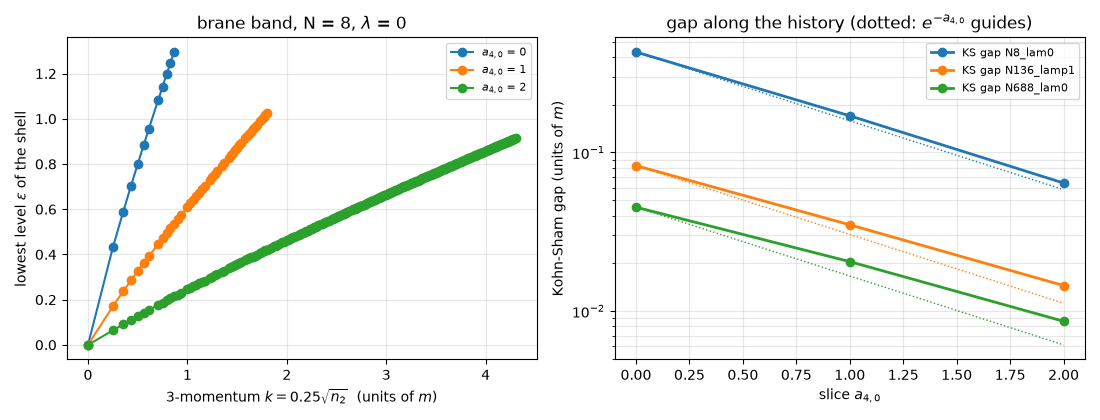

figure saved: <output>/figures/figure1_brane_band.png | sha256 ab407444808dc130f25d6ec50b91d3855d7c5b12d97741a33a48a54dd3899e05


In [10]:
def save_and_show(fig, name):
    path = FIG_DIR / name
    fig.savefig(path, format="png", dpi=100, metadata={"Software": None})
    plt.close(fig)
    display(Image(data=path.read_bytes()))
    print("figure saved:", shown(path), "| sha256", sha256(path))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for rid, colour in (("N8_lam0_a00", "C0"), ("N8_lam0_a10", "C1"), ("N8_lam0_a20", "C2")):
    band = {}
    for l in RESULTS[rid]["levels_n2_j_parity_label_eps_deg_f"]:
        if l[1] == 1 and l[2] == "even":
            band[l[0]] = min(band.get(l[0], np.inf), l[4])
    shells = sorted(band)
    ax1.plot([0.25 * np.sqrt(n) for n in shells], [band[n] for n in shells], "o-", color=colour,
             label=f"$a_{{4,0}}$ = {RESULTS[rid]['parameters']['a4']:.0f}")
ax1.set_xlabel(r"3-momentum $k = 0.25\sqrt{n_2}$  (units of $m$)")
ax1.set_ylabel(r"lowest level $\varepsilon$ of the shell")
ax1.set_title("brane band, N = 8, $\\lambda$ = 0")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
a4s = np.array(SLICES)
for prefix, colour in (("N8_lam0", "C0"), ("N136_lamp1", "C1"), ("N688_lam0", "C2")):
    gaps = np.array([DERIVED[f"{prefix}_a{int(10 * a):02d}"]["KS_gap"] for a in SLICES])
    ax2.semilogy(a4s, gaps, "o-", color=colour, lw=2, label=f"KS gap {prefix}")
    ax2.semilogy(a4s, gaps[0] * np.exp(-a4s), ":", color=colour, lw=1)
ax2.set_xlabel(r"slice $a_{4,0}$")
ax2.set_ylabel("Kohn-Sham gap (units of $m$)")
ax2.set_title(r"gap along the history (dotted: $e^{-a_{4,0}}$ guides)")
ax2.legend(fontsize=8)
ax2.grid(True, which="both", alpha=0.3)
fig.tight_layout()
save_and_show(fig, "figure1_brane_band.png")

### 10.2 Figure 2: profiles in the hidden direction

The proper densities and pressures of the state N = 136, $\lambda = +\lambda_1$, $a_{4,0} = 1$ along
the hidden coordinate $y$ (brane at $y = 0$, tip at $y = -3$), read from the profile file the solver
has just written. Left: the particle density $n$ and the energy density $\rho$ (logarithmic scale):
they grow toward the tip, where the proper 7-volume element $e^{6Hy}$ is small. Right: the
pressures $p_3$, $p_t$, $p_8$ divided by $\rho$; the extra-time pressure $p_t = e_\mathrm{int}$ is small
because it comes only from the interaction.

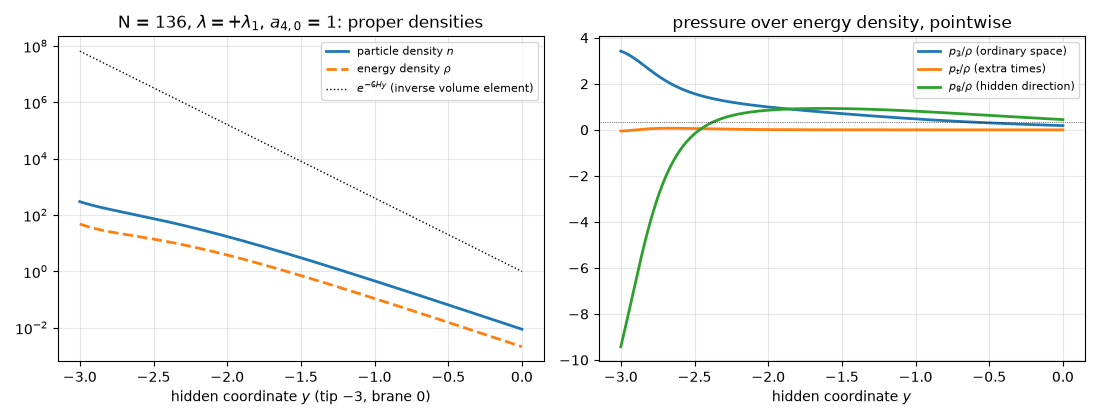

figure saved: <output>/figures/figure2_profiles.png | sha256 19a9faee574767cb041a3dce43f6f6a429c507baf6fdf1da3dbf5c95d7faafb7
max |M_eff - m| = 5.911e-02 m, max |v_v| = 1.736e-02 m (the self-consistent mean field of this weakly coupled state)


In [11]:
prof = read_csv(RUN_DIR / "N136_lamp1_a10.csv")
y = np.array([float(r["y"]) for r in prof])
col = {k: np.array([float(r[k]) for r in prof]) for k in ("n", "S", "rho", "p3", "p_t", "p8", "M_eff", "v_v")}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.semilogy(y, col["n"], lw=2, label="particle density $n$")
ax1.semilogy(y, col["rho"], lw=2, ls="--", label=r"energy density $\rho$")
ax1.semilogy(y, np.exp(-6 * y), lw=1, ls=":", color="k", label=r"$e^{-6Hy}$ (inverse volume element)")
ax1.set_xlabel("hidden coordinate $y$ (tip $-3$, brane 0)")
ax1.set_title("N = 136, $\\lambda = +\\lambda_1$, $a_{4,0}$ = 1: proper densities")
ax1.legend(fontsize=8)
ax1.grid(True, which="both", alpha=0.3)
for k, label in (("p3", r"$p_3/\rho$ (ordinary space)"), ("p_t", r"$p_t/\rho$ (extra times)"),
                 ("p8", r"$p_8/\rho$ (hidden direction)")):
    ax2.plot(y, col[k] / col["rho"], lw=2, label=label)
ax2.axhline(1 / 3, color="k", lw=0.5, ls=":")
ax2.set_xlabel("hidden coordinate $y$")
ax2.set_title("pressure over energy density, pointwise")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
fig.tight_layout()
save_and_show(fig, "figure2_profiles.png")
print(f"max |M_eff - m| = {np.max(np.abs(col['M_eff'] - 1)):.3e} m, max |v_v| = {np.max(np.abs(col['v_v'])):.3e} m "
      "(the self-consistent mean field of this weakly coupled state)")

### 10.3 Figure 3: energy and integrated pressures along the history

Left: the Kohn-Sham energy $E_\mathrm{KS}$ of the N = 136 and N = 688 series against $a_{4,0}$
(logarithmic scale): the gas loses energy as its 3-momenta redshift, roughly like $e^{-a_{4,0}}$.
Right: the ratios $P_3/E$ and $P_8/E$ of the integrated pressures; $P_3/E$ approaches $1/3$, the value
of a massless (radiation-like) gas.

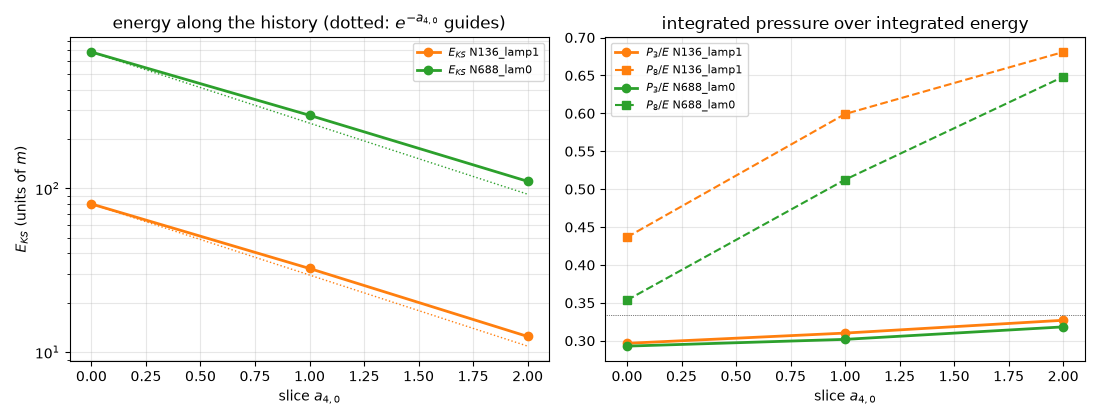

figure saved: <output>/figures/figure3_history.png | sha256 bb156c2d7e822b6d4e0dfabce155e6ced1008fb62465da5d1ba9ed2491cb7623


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for prefix, colour in (("N136_lamp1", "C1"), ("N688_lam0", "C2")):
    ids = [f"{prefix}_a{int(10 * a):02d}" for a in SLICES]
    E = np.array([RESULTS[i]["E_KS"] for i in ids])
    ax1.semilogy(a4s, E, "o-", color=colour, lw=2, label=f"$E_{{KS}}$ {prefix}")
    ax1.semilogy(a4s, E[0] * np.exp(-a4s), ":", color=colour, lw=1)
    emts = [RESULTS[i]["emtIntegrals_2Vol7_int_e6Hy"] for i in ids]
    ax2.plot(a4s, [e["p3"] / e["rho"] for e in emts], "o-", color=colour, lw=2, label=f"$P_3/E$ {prefix}")
    ax2.plot(a4s, [e["p8"] / e["rho"] for e in emts], "s--", color=colour, lw=1.5, label=f"$P_8/E$ {prefix}")
ax2.axhline(1 / 3, color="k", lw=0.5, ls=":")
ax1.set_xlabel(r"slice $a_{4,0}$")
ax1.set_ylabel("$E_{KS}$ (units of $m$)")
ax1.set_title(r"energy along the history (dotted: $e^{-a_{4,0}}$ guides)")
ax1.legend(fontsize=8)
ax1.grid(True, which="both", alpha=0.3)
ax2.set_xlabel(r"slice $a_{4,0}$")
ax2.set_title("integrated pressure over integrated energy")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
fig.tight_layout()
save_and_show(fig, "figure3_history.png")

### 10.4 Figure 4: how close the Rust solver and the independent reference are

For each state and quantity compared in section 9.1, the ratio of $|\text{this notebook} -
\text{reference}|$ to the tolerance of the committed cross-check (logarithmic scale; a ratio below 1
passes). Exact zeros (for example $P_t$ at $\lambda = 0$) are drawn at the bottom edge.

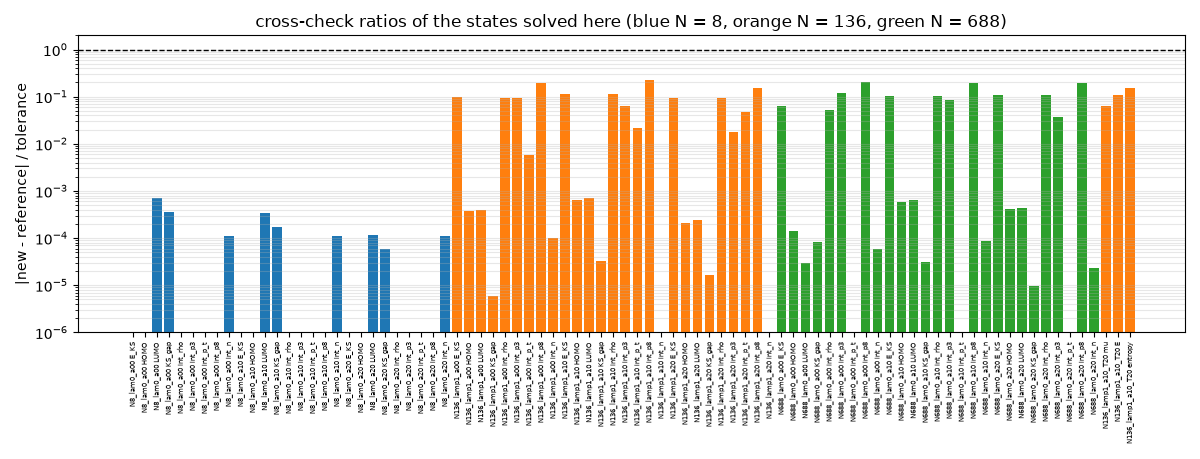

figure saved: <output>/figures/figure4_crosscheck.png | sha256 da9d08900b2cf2d1966e45b8174121d87c7822e9aaec28b9c8144ca2c9129d7f


In [13]:
labels = [f"{rid}\n{q}" for (rid, q) in XC_RATIOS]
values = np.array([max(v, 1e-6) for v in XC_RATIOS.values()])
fig, ax = plt.subplots(figsize=(12, 4.6))
ax.bar(np.arange(len(values)), values, color=["C0" if "N8" in l else "C1" if "N136" in l else "C2" for l in labels])
ax.set_yscale("log")
ax.set_ylim(1e-6, 2)
ax.axhline(1.0, color="k", lw=1, ls="--")
ax.set_xticks(np.arange(len(values)), [l.replace("\n", " ") for l in labels], rotation=90, fontsize=5)
ax.set_ylabel("|new - reference| / tolerance")
ax.set_title("cross-check ratios of the states solved here (blue N = 8, orange N = 136, green N = 688)")
ax.grid(True, axis="y", which="both", alpha=0.3)
fig.tight_layout()
save_and_show(fig, "figure4_crosscheck.png")

### 10.5 Summary of this notebook's checks

The last code cell counts the checks of this notebook (each printed a PASS line above; a failure
would have stopped the notebook at that point) and lists the files written into `<output>`.

In [14]:
print(f"checks of this notebook: {len(CHECKS)} passed, 0 failed")
for path in sorted(p for p in OUT.rglob("*") if p.is_file() and "cargo-target" not in p.parts):
    print(f"  {shown(path):42s} {path.stat().st_size:7d} bytes")

checks of this notebook: 24 passed, 0 failed
  <output>/figures/figure1_brane_band.png      86018 bytes
  <output>/figures/figure2_profiles.png        64480 bytes
  <output>/figures/figure3_history.png         80021 bytes
  <output>/figures/figure4_crosscheck.png      95134 bytes
  <output>/ks_runs/N136_lamp1_a00.csv          38057 bytes
  <output>/ks_runs/N136_lamp1_a00.json         12834 bytes
  <output>/ks_runs/N136_lamp1_a10.csv          37922 bytes
  <output>/ks_runs/N136_lamp1_a10.json         28182 bytes
  <output>/ks_runs/N136_lamp1_a10_T20.json     17420 bytes
  <output>/ks_runs/N136_lamp1_a20.csv          38032 bytes
  <output>/ks_runs/N136_lamp1_a20.json        110731 bytes
  <output>/ks_runs/N688_lam0_a00.csv           37158 bytes
  <output>/ks_runs/N688_lam0_a00.json          21151 bytes
  <output>/ks_runs/N688_lam0_a10.csv           37038 bytes
  <output>/ks_runs/N688_lam0_a10.json          40344 bytes
  <output>/ks_runs/N688_lam0_a20.csv           37121 bytes
  <output>/

## 11. What this notebook showed, and what it did not show

**Showed.**

- The Revision Kohn-Sham solver builds without warnings, checks its inputs (the functional's
  coefficients 15/16 and -1/16, the author's gamma matrices, the exact $2 \times 2$ block reduction)
  and runs with the parameters of the committed record.
- Ten canonical states solved anew (N = 8, 136, 688 at $a_{4,0} = 0, 1, 2$, and one thermal state)
  reproduce the committed record exactly: energies, iterations, residuals, HOMO, LUMO, gap, every
  level and every EMT integral as equal floating-point numbers, and the profile files byte for byte;
  the thermal state's $\mu$, $E$ and entropy equal the committed thermodynamics.
- Along the prescribed deflating history the brane band redshifts: the N = 8 gap falls from
  0.4307 to 0.0642, the gas energy falls, and the integrated ratio $P_3/E$ rises toward 1/3.
- The new numbers agree with the independent Python reference within the committed cross-check's
  tolerances, and the seven committed Kohn-Sham reports record 46, 58, 42, 14, 5, 37 and 31 checks,
  all passed.

**Did not show.**

- It does not re-run the whole canonical matrix (75 ground states, 135 thermal states, the
  excited, adiabatic, rescaling and exact-Fock outputs), the determinism and refinement comparison,
  the reference or the cross-check; it reads their committed reports.
- The history $a_4 = A H x_4$ is prescribed: these are test-field states without back-reaction, not
  a solution of the $a_4$ field equations with this source; the states are instantaneous, and the
  time-dependent problem is OPEN.
- The $Z_2$ brane is ASSUMED, the tip at $L = 3$ is a cutoff, and the filling of the positive branch is
  a CONVENTION whose justification is OPEN; no correlation energy is included.
- Nothing here is an equation of state seen by a 3-space observer; that question, and the
  comparison with the Supernovae Unite values, belong to the dark-sector notebook.